# Screw Detection & Classification — End-to-End

**One notebook covering the entire pipeline** for industrial screw images organised as:

```
data/raw/
├── Ecrou NOK/   ├── Ecrou OK/
├── Rondelle NOK/├── Rondelle OK/
└── Vis NOK/    └── Vis OK/
```

Runs identically **locally** and on **Google Colab** (auto-mounts Drive).

## What this notebook does

1. **Environment & paths** — detect Colab vs. local, mount Drive, locate `data/raw/`.
2. **Dataset inspection** — scan the six class folders, write train/val/test CSV splits + class mapping.
3. **Visual exploration** — class distribution, image-size statistics, sample grid.
4. **Classical CV pipeline (OpenCV)** — CLAHE → Otsu → morphology → connected components → contour features + Hu moments → rule-based family classifier.
5. **Deep-learning classification** — fine-tune **ConvNeXt-Tiny** (ImageNet-pretrained) on the 6-class problem, full 25-epoch schedule, AdamW + cosine warm-up, AMP, RandAugment + RandomErasing, horizontal-flip TTA.
6. **Evaluation** — macro-F1 (headline), per-class metrics, confusion matrix, failure cases.
7. **Grad-CAM** — visual explanations on correctly / incorrectly classified samples.
8. **Reporting** — write `results/run_summary.json`, `results/metrics.csv`, regenerate `report.md` numbers.

Run top-to-bottom. Tune `MODE` in cell 1 to switch between `debug / mini / medium / full`.


## 0 · Configuration

In [3]:
MODE          = "full"
MODEL_NAME    = "convnext_tiny"
IMG_SIZE      = 224
BATCH_SIZE    = 32
SEED          = 42
VAL_FRAC      = 0.15
TEST_FRAC     = 0.15
NUM_WORKERS   = 2

MODE_EPOCHS   = {"debug": 1, "mini": 5, "medium": 15, "full": 25}
EPOCHS        = MODE_EPOCHS[MODE]
print(f"MODE={MODE}  →  EPOCHS={EPOCHS}")

MODE=full  →  EPOCHS=25


## 1 · Environment & paths (Colab + local)

In [4]:
import os, sys, json, time, random, shutil, subprocess, warnings, glob
from pathlib import Path
warnings.filterwarnings("ignore")

def _on_colab() -> bool:
    try:
        import google.colab
        return True
    except ImportError:
        return False

ON_COLAB = _on_colab()

if ON_COLAB:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
    candidates = [
        Path("/content/drive/MyDrive/screw_project"),
        Path("/content/drive/MyDrive/screw_classification"),
        Path("/content/screw_project"),
    ]
    PROJECT_ROOT = next((c for c in candidates if (c / "data" / "raw").exists()), candidates[0])
    if not (PROJECT_ROOT / "data" / "raw").exists():
        hits = glob.glob("/content/drive/MyDrive/**/data/raw", recursive=True)
        if hits:
            PROJECT_ROOT = Path(hits[0]).parent.parent
else:
    PROJECT_ROOT = Path.cwd()

DATA_DIR     = PROJECT_ROOT / "data"
RAW_DIR      = DATA_DIR / "raw"
SPLITS_DIR   = DATA_DIR / "splits"
RESULTS_DIR  = PROJECT_ROOT / "results"
FIG_DIR      = RESULTS_DIR / "figures"
CKPT_DIR     = RESULTS_DIR / "checkpoints"
GRADCAM_DIR  = RESULTS_DIR / "gradcam"
CLASSICAL_DIR= RESULTS_DIR / "classical"
for d in (SPLITS_DIR, RESULTS_DIR, FIG_DIR, CKPT_DIR, GRADCAM_DIR, CLASSICAL_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Colab        : {ON_COLAB}")
print(f"Project root : {PROJECT_ROOT}")
print(f"Raw data     : {RAW_DIR}   exists={RAW_DIR.exists()}")

Mounted at /content/drive
Colab        : True
Project root : /content/drive/MyDrive/screw_classification
Raw data     : /content/drive/MyDrive/screw_classification/data/raw   exists=True


## 2 · Install / import dependencies

In [5]:
REQS = ["opencv-python", "numpy", "pandas", "matplotlib", "seaborn",
        "scikit-image", "scikit-learn", "timm", "tqdm", "Pillow"]
missing = []
_alias = {"opencv-python": "cv2", "Pillow": "PIL", "scikit-image": "skimage",
          "scikit-learn": "sklearn"}
for r in REQS:
    mod = _alias.get(r, r)
    try:
        __import__(mod)
    except ImportError:
        missing.append(r)
if missing:
    print("Installing:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import numpy as np, pandas as pd, cv2, matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Torch {torch.__version__}  device={DEVICE}")

Torch 2.10.0+cu128  device=cuda


## 3 · Inspect dataset → write splits

In [6]:
CLASSES = ["Ecrou NOK", "Ecrou OK",
           "Rondelle NOK", "Rondelle OK",
           "Vis NOK", "Vis OK"]
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}
IDX2CLASS = {i: c for c, i in CLASS2IDX.items()}
IMG_EXTS  = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

def _find_class_root(raw: Path) -> Path:
    """Accept either data/raw/<class>/imgs or data/raw/<inner>/<class>/imgs."""
    if any((raw / c).is_dir() for c in CLASSES):
        return raw
    for sub in raw.iterdir() if raw.exists() else []:
        if sub.is_dir() and any((sub / c).is_dir() for c in CLASSES):
            return sub
    return raw

CLASS_ROOT = _find_class_root(RAW_DIR)
print(f"Class folders under: {CLASS_ROOT}")

rows = []
for cls in CLASSES:
    folder = CLASS_ROOT / cls
    if not folder.is_dir():
        print(f"  ⚠ missing class folder: {cls}")
        continue
    for p in folder.rglob("*"):
        if p.suffix.lower() in IMG_EXTS:
            rows.append({"path": str(p), "class": cls, "label": CLASS2IDX[cls]})
df = pd.DataFrame(rows)
assert not df.empty, f"No images found under {CLASS_ROOT} — check your data/raw/ layout."
print(f"Total images: {len(df)}")
print(df['class'].value_counts().to_string())

Class folders under: /content/drive/MyDrive/screw_classification/data/raw
Total images: 3000
class
Ecrou NOK       500
Ecrou OK        500
Rondelle NOK    500
Rondelle OK     500
Vis NOK         500
Vis OK          500


In [7]:
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(df, test_size=VAL_FRAC + TEST_FRAC,
                                     stratify=df['label'], random_state=SEED)
rel_test = TEST_FRAC / (VAL_FRAC + TEST_FRAC)
val_df, test_df = train_test_split(temp_df, test_size=rel_test,
                                   stratify=temp_df['label'], random_state=SEED)
train_df.to_csv(SPLITS_DIR / "train.csv", index=False)
val_df  .to_csv(SPLITS_DIR / "val.csv",   index=False)
test_df .to_csv(SPLITS_DIR / "test.csv",  index=False)
with open(SPLITS_DIR / "class_mapping.json", "w") as f:
    json.dump(CLASS2IDX, f, indent=2)
print(f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}")

train=2100  val=450  test=450


## 4 · Exploratory visualisation

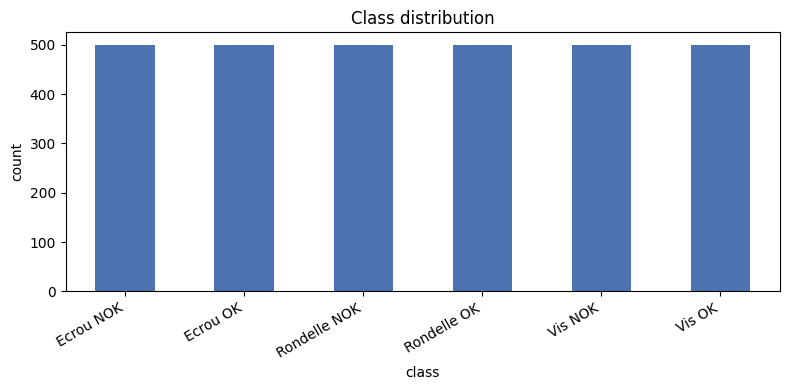

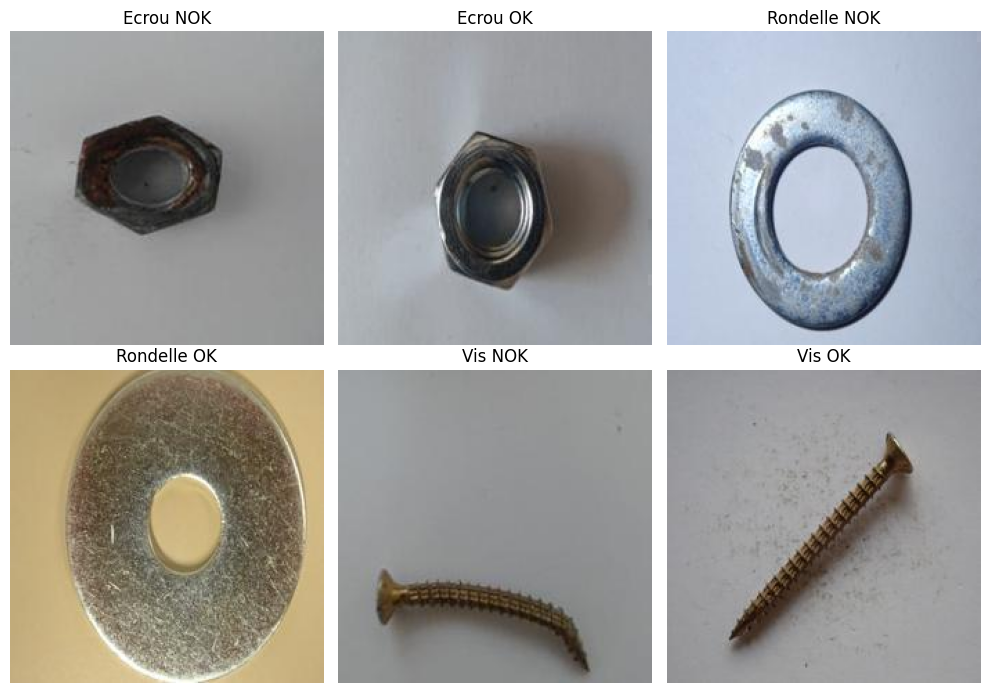

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
df['class'].value_counts().reindex(CLASSES).plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_title('Class distribution'); ax.set_ylabel('count')
plt.xticks(rotation=30, ha='right'); plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution.png", dpi=120); plt.show()

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
for ax, cls in zip(axes.flat, CLASSES):
    sub = df[df['class'] == cls]
    if sub.empty:
        ax.set_visible(False); continue
    img = cv2.cvtColor(cv2.imread(sub.iloc[0]['path']), cv2.COLOR_BGR2RGB)
    ax.imshow(img); ax.set_title(cls); ax.axis('off')
plt.tight_layout(); plt.savefig(FIG_DIR / "sample_grid.png", dpi=120); plt.show()

## 5 · Classical CV pipeline (OpenCV-only)

Per-image: CLAHE → Otsu → morphology → connected components → contour features + Hu moments → rule-based **family** (screw / nut / washer).

Note: the rule classifier identifies the *object family*, not OK/NOK. The deep-learning section below handles the 6-class OK/NOK discrimination.

In [9]:
def preprocess(bgr):
    gray  = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray  = clahe.apply(gray)
    return cv2.GaussianBlur(gray, (5, 5), 0)

def segment(gray):
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN,  k, iterations=1)
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, k, iterations=2)
    return th

def largest_contour_features(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    cnt = max(contours, key=cv2.contourArea)
    area  = cv2.contourArea(cnt)
    if area < 50:
        return None
    peri  = cv2.arcLength(cnt, True)
    x, y, w, h = cv2.boundingRect(cnt)
    aspect = max(w, h) / max(min(w, h), 1)
    extent = area / max(w * h, 1)
    circ   = 4 * np.pi * area / max(peri ** 2, 1)
    hu     = cv2.HuMoments(cv2.moments(cnt)).flatten()
    return dict(area=area, perimeter=peri, aspect_ratio=aspect,
                extent=extent, circularity=circ,
                **{f"hu{i+1}": float(v) for i, v in enumerate(hu)})

def family_rule(feat):
    if feat['aspect_ratio'] > 2.2:  return 'Vis'
    if feat['circularity']  > 0.78: return 'Rondelle'
    return 'Ecrou'

sample_for_classical = df.sample(min(200, len(df)), random_state=SEED)
feat_rows = []
for _, r in tqdm(sample_for_classical.iterrows(), total=len(sample_for_classical),
                 desc="classical"):
    bgr = cv2.imread(r['path'])
    if bgr is None:
        continue
    gray = preprocess(bgr); mask = segment(gray)
    feat = largest_contour_features(mask)
    if feat is None:
        continue
    feat['path'] = r['path']
    feat['true_class']  = r['class']
    feat['true_family'] = r['class'].split()[0]
    feat['pred_family'] = family_rule(feat)
    feat_rows.append(feat)
classical_df = pd.DataFrame(feat_rows)
classical_df.to_csv(CLASSICAL_DIR / "features.csv", index=False)

family_acc = (classical_df['true_family'] == classical_df['pred_family']).mean()
print(f"Classical family-classifier accuracy on {len(classical_df)} samples: {family_acc:.3f}")

classical:   0%|          | 0/200 [00:00<?, ?it/s]

Classical family-classifier accuracy on 200 samples: 0.410


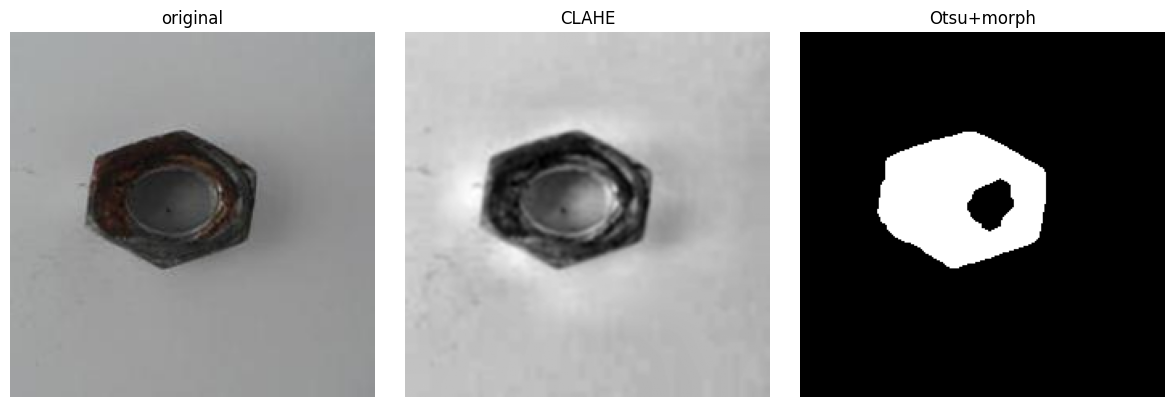

In [10]:
sample_path = df.iloc[0]['path']
bgr  = cv2.imread(sample_path)
gray = preprocess(bgr); mask = segment(gray)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)); axes[0].set_title('original');  axes[0].axis('off')
axes[1].imshow(gray, cmap='gray');                    axes[1].set_title('CLAHE');     axes[1].axis('off')
axes[2].imshow(mask, cmap='gray');                    axes[2].set_title('Otsu+morph'); axes[2].axis('off')
plt.tight_layout(); plt.savefig(FIG_DIR / "classical_stages.png", dpi=120); plt.show()

## 6 · Deep-learning dataset + transforms

In [11]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.25),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class ScrewDataset(Dataset):
    def __init__(self, frame, tf):
        self.frame = frame.reset_index(drop=True)
        self.tf    = tf
    def __len__(self):  return len(self.frame)
    def __getitem__(self, i):
        row = self.frame.iloc[i]
        img = Image.open(row['path']).convert('RGB')
        return self.tf(img), int(row['label'])

train_ds = ScrewDataset(train_df, train_tf)
val_ds   = ScrewDataset(val_df,   eval_tf)
test_ds  = ScrewDataset(test_df,  eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
print(f"loaders ready  |  train batches={len(train_loader)}  val={len(val_loader)}  test={len(test_loader)}")

loaders ready  |  train batches=65  val=15  test=15


## 7 · Build ConvNeXt-Tiny (ImageNet-pretrained)

In [12]:
model = timm.create_model(MODEL_NAME, pretrained=True,
                          num_classes=len(CLASSES)).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"{MODEL_NAME}  |  {n_params:.1f}M params  |  num_classes={len(CLASSES)}")

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

convnext_tiny  |  27.8M params  |  num_classes=6


## 8 · Train (AdamW + cosine warm-up + AMP)

In [13]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
warmup    = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, total_iters=3)
cosine    = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(EPOCHS - 3, 1))
scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, [warmup, cosine], milestones=[3])
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
scaler    = torch.cuda.amp.GradScaler(enabled=DEVICE.type == "cuda")

def epoch_loop(loader, training):
    model.train(training)
    tot, correct, loss_sum = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=DEVICE.type == "cuda"):
            logits = model(x); loss = criterion(logits, y)
        if training:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update()
        loss_sum += loss.item() * x.size(0)
        correct  += (logits.argmax(1) == y).sum().item()
        tot      += x.size(0)
    return loss_sum / tot, correct / tot

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc, best_path = 0.0, CKPT_DIR / f"{MODEL_NAME}_best.pth"

for ep in range(1, EPOCHS + 1):
    t0 = time.time()
    tl, ta = epoch_loop(train_loader, training=True)
    with torch.no_grad():
        vl, va = epoch_loop(val_loader, training=False)
    scheduler.step()
    history["train_loss"].append(tl); history["train_acc"].append(ta)
    history["val_loss"]  .append(vl); history["val_acc"]  .append(va)
    flag = ""
    if va > best_val_acc:
        best_val_acc = va
        torch.save({"model": model.state_dict(),
                    "classes": CLASSES, "epoch": ep, "val_acc": va}, best_path)
        flag = " ★ best"
    print(f"ep {ep:02d}/{EPOCHS}  train_loss={tl:.4f} acc={ta:.3f}  "
          f"val_loss={vl:.4f} acc={va:.3f}  ({time.time()-t0:.1f}s){flag}")
print(f"Best val acc: {best_val_acc:.3f}  →  {best_path}")

ep 01/25  train_loss=0.6522 acc=0.816  val_loss=0.4237 acc=0.924  (309.1s) ★ best
ep 02/25  train_loss=0.5295 acc=0.880  val_loss=0.2910 acc=0.987  (11.1s) ★ best
ep 03/25  train_loss=0.4268 acc=0.927  val_loss=0.3963 acc=0.931  (8.0s)
ep 04/25  train_loss=0.4464 acc=0.918  val_loss=0.3466 acc=0.962  (10.1s)
ep 05/25  train_loss=0.4315 acc=0.923  val_loss=0.3381 acc=0.958  (8.6s)
ep 06/25  train_loss=0.3902 acc=0.937  val_loss=0.3050 acc=0.976  (8.4s)
ep 07/25  train_loss=0.3681 acc=0.944  val_loss=0.3795 acc=0.933  (8.2s)
ep 08/25  train_loss=0.3949 acc=0.934  val_loss=0.3430 acc=0.951  (8.4s)
ep 09/25  train_loss=0.3232 acc=0.968  val_loss=0.3392 acc=0.969  (8.2s)
ep 10/25  train_loss=0.3283 acc=0.963  val_loss=0.2737 acc=0.984  (8.0s)
ep 11/25  train_loss=0.3397 acc=0.959  val_loss=0.3198 acc=0.971  (8.1s)
ep 12/25  train_loss=0.3249 acc=0.965  val_loss=0.3307 acc=0.964  (8.0s)
ep 13/25  train_loss=0.3123 acc=0.969  val_loss=0.2842 acc=0.978  (8.7s)
ep 14/25  train_loss=0.2862 acc=0

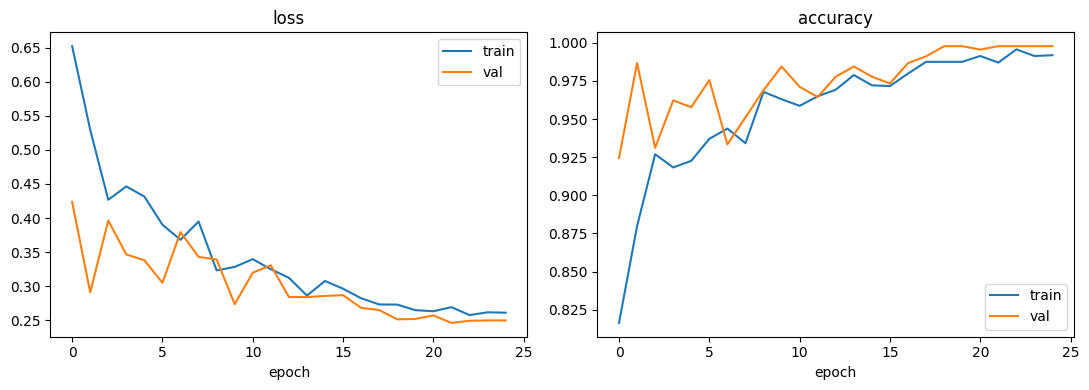

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history['train_loss'], label='train'); ax[0].plot(history['val_loss'], label='val')
ax[0].set_title('loss');     ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(history['train_acc'],  label='train'); ax[1].plot(history['val_acc'],  label='val')
ax[1].set_title('accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "training_curves.png", dpi=120); plt.show()

## 9 · Evaluate on test split (with horizontal-flip TTA)

In [15]:
ckpt = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(ckpt['model']); model.eval()

all_y, all_p = [], []
with torch.no_grad():
    for x, y in tqdm(test_loader, desc='test'):
        x, y = x.to(DEVICE), y.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=DEVICE.type == 'cuda'):
            logits = model(x)
            logits = logits + model(torch.flip(x, dims=[3]))  # H-flip TTA
        all_p.append(logits.argmax(1).cpu().numpy()); all_y.append(y.cpu().numpy())
y_true = np.concatenate(all_y); y_pred = np.concatenate(all_p)

acc      = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro')
print(f"Test accuracy : {acc:.4f}")
print(f"Test macro-F1 : {macro_f1:.4f}   ← headline")
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

test:   0%|          | 0/15 [00:00<?, ?it/s]

Test accuracy : 0.9889
Test macro-F1 : 0.9889   ← headline
              precision    recall  f1-score   support

   Ecrou NOK     1.0000    1.0000    1.0000        75
    Ecrou OK     1.0000    1.0000    1.0000        75
Rondelle NOK     1.0000    0.9733    0.9865        75
 Rondelle OK     0.9740    1.0000    0.9868        75
     Vis NOK     1.0000    0.9600    0.9796        75
      Vis OK     0.9615    1.0000    0.9804        75

    accuracy                         0.9889       450
   macro avg     0.9893    0.9889    0.9889       450
weighted avg     0.9893    0.9889    0.9889       450



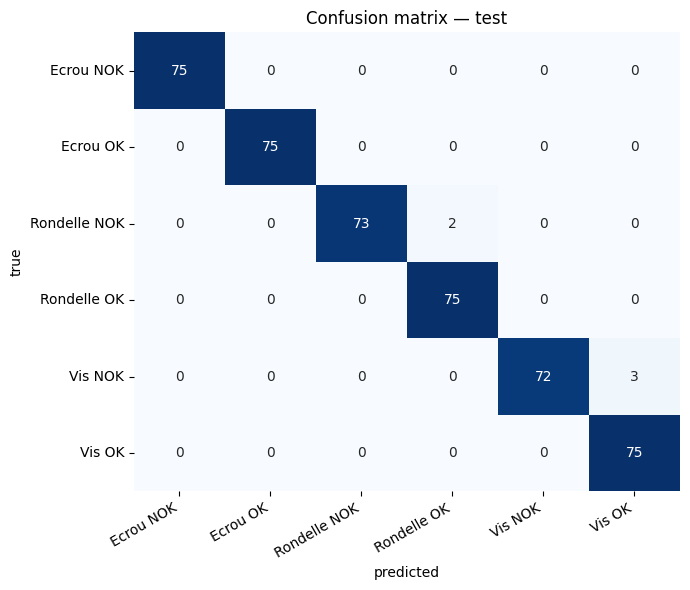

,precision,recall,f1-score,support
Ecrou NOK,1.0000,1.0000,1.0000,75.0000
Ecrou OK,1.0000,1.0000,1.0000,75.0000
Rondelle NOK,1.0000,0.9733,0.9865,75.0000
Rondelle OK,0.9740,1.0000,0.9868,75.0000
Vis NOK,1.0000,0.9600,0.9796,75.0000
Vis OK,0.9615,1.0000,0.9804,75.0000
accuracy,0.9889,0.9889,0.9889,0.9889
macro avg,0.9893,0.9889,0.9889,450.0000
weighted avg,0.9893,0.9889,0.9889,450.0000


In [16]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, cbar=False)
plt.xlabel('predicted'); plt.ylabel('true'); plt.title('Confusion matrix — test')
plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.savefig(FIG_DIR / "confusion_matrix.png", dpi=120); plt.show()

rep = classification_report(y_true, y_pred, target_names=CLASSES,
                            digits=4, output_dict=True)
per_class_df = pd.DataFrame(rep).T.round(4)
per_class_df.to_csv(RESULTS_DIR / "metrics.csv")
per_class_df.head(10)

## 10 · Failure cases

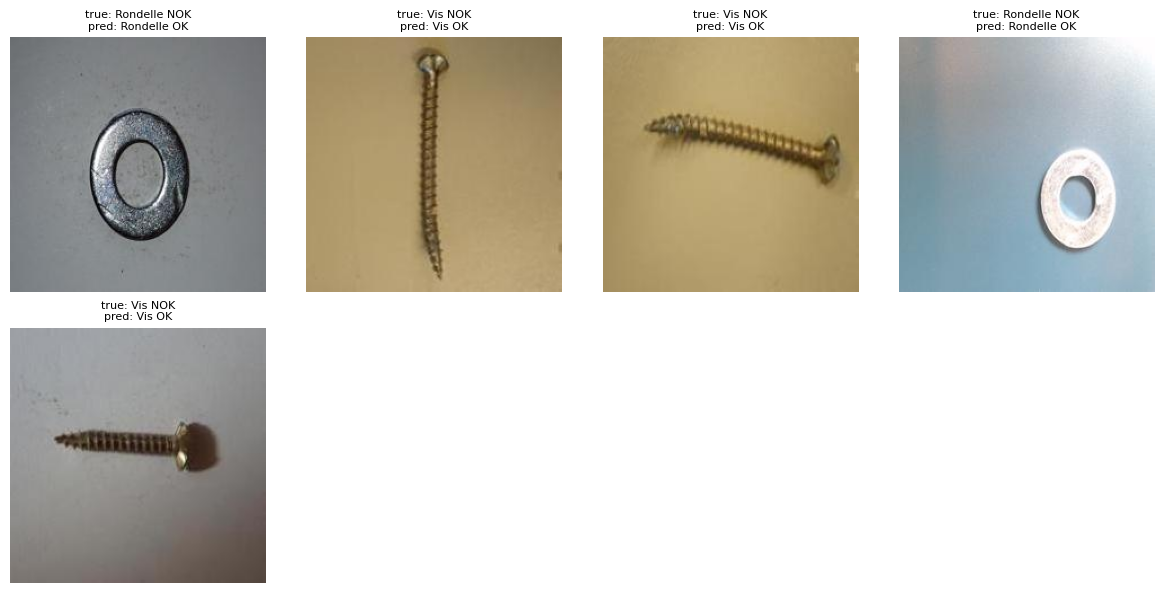

In [17]:
wrong = np.where(y_true != y_pred)[0]
if wrong.size:
    show = wrong[:8]
    cols = min(4, len(show)); rows = int(np.ceil(len(show) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.atleast_1d(axes).flatten()
    test_paths = test_df.reset_index(drop=True)['path'].tolist()
    for ax, idx in zip(axes, show):
        img = cv2.cvtColor(cv2.imread(test_paths[idx]), cv2.COLOR_BGR2RGB)
        ax.imshow(img); ax.axis('off')
        ax.set_title(f"true: {IDX2CLASS[y_true[idx]]}\npred: {IDX2CLASS[y_pred[idx]]}",
                     fontsize=8)
    for ax in axes[len(show):]: ax.set_visible(False)
    plt.tight_layout(); plt.savefig(FIG_DIR / "failure_cases.png", dpi=120); plt.show()
else:
    print("No mistakes on the test split.")

## 11 · Grad-CAM explanations

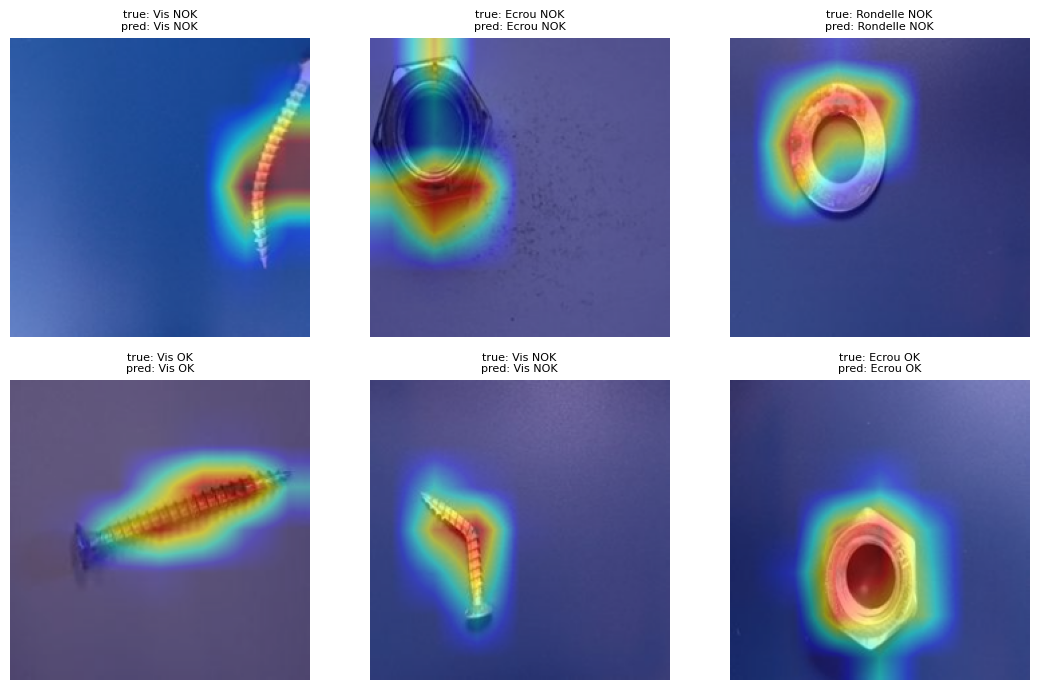

In [18]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model; self.acts = None; self.grads = None
        target_layer.register_forward_hook(self._fwd)
        target_layer.register_full_backward_hook(self._bwd)
    def _fwd(self, _m, _i, out):           self.acts  = out.detach()
    def _bwd(self, _m, _gi, gout):         self.grads = gout[0].detach()
    def __call__(self, x, cls_idx):
        self.model.zero_grad()
        logits = self.model(x)
        logits[0, cls_idx].backward()
        w   = self.grads.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((w * self.acts).sum(1, keepdim=True))
        cam = F.interpolate(cam, size=x.shape[-2:], mode='bilinear', align_corners=False)
        cam = cam[0, 0].cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

target_layer = model.stages[-1] if hasattr(model, 'stages') else list(model.modules())[-3]
cam_engine = GradCAM(model, target_layer)

def overlay_cam(rgb, cam, alpha=0.45):
    heat = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
    return np.clip((1 - alpha) * rgb + alpha * heat, 0, 255).astype(np.uint8)

model.eval()
samples = test_df.sample(min(6, len(test_df)), random_state=SEED).reset_index(drop=True)
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for ax, (_, r) in zip(axes.flat, samples.iterrows()):
    img = Image.open(r['path']).convert('RGB')
    x   = eval_tf(img).unsqueeze(0).to(DEVICE).requires_grad_()
    with torch.enable_grad():
        pred = model(x).argmax(1).item()
        cam  = cam_engine(x, pred)
    rgb = np.array(img.resize((IMG_SIZE, IMG_SIZE)))
    ax.imshow(overlay_cam(rgb, cam))
    ax.set_title(f"true: {r['class']}\npred: {IDX2CLASS[pred]}", fontsize=8)
    ax.axis('off')
plt.tight_layout(); plt.savefig(GRADCAM_DIR / "gradcam_grid.png", dpi=120); plt.show()

## 12 · Persist run summary + regenerate report

In [19]:
summary = {
    "mode":             MODE,
    "epochs":           EPOCHS,
    "model":            MODEL_NAME,
    "num_params_M":     round(n_params, 2),
    "n_train":          len(train_df),
    "n_val":            len(val_df),
    "n_test":           len(test_df),
    "best_val_acc":     round(best_val_acc, 4),
    "test_accuracy":    round(float(acc), 4),
    "test_macro_f1":    round(float(macro_f1), 4),
    "classical_family_acc": round(float(family_acc), 4),
    "device":           str(DEVICE),
}
with open(RESULTS_DIR / "run_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))

{
  "mode": "full",
  "epochs": 25,
  "model": "convnext_tiny",
  "num_params_M": 27.82,
  "n_train": 2100,
  "n_val": 450,
  "n_test": 450,
  "best_val_acc": 0.9978,
  "test_accuracy": 0.9889,
  "test_macro_f1": 0.9889,
  "classical_family_acc": 0.41,
  "device": "cuda"
}


In [20]:
report_path = PROJECT_ROOT / "report.md"
per_class_md = per_class_df.loc[CLASSES][["precision", "recall", "f1-score", "support"]].to_markdown()
results_block = f"""

## Run results ({time.strftime('%Y-%m-%d %H:%M')})

- Model: **{MODEL_NAME}** ({n_params:.1f}M params), epochs={EPOCHS}, mode={MODE}
- Splits: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}
- **Test macro-F1: {macro_f1:.4f}**, accuracy: {acc:.4f}
- Classical family-classifier accuracy: {family_acc:.4f}

### Per-class metrics

{per_class_md}

Artifacts: `results/metrics.csv`, `results/run_summary.json`,
`results/figures/{{confusion_matrix,training_curves,failure_cases}}.png`,
`results/gradcam/gradcam_grid.png`.
"""
with open(report_path, "a") as f:
    f.write(results_block)
print(f"Appended results to {report_path}")

Appended results to /content/drive/MyDrive/screw_classification/report.md


---
**Outputs.**

- `data/splits/{train,val,test}.csv`, `class_mapping.json`
- `results/metrics.csv`, `results/run_summary.json`
- `results/checkpoints/convnext_tiny_best.pth`
- `results/classical/features.csv`
- `results/figures/{class_distribution,sample_grid,classical_stages,training_curves,confusion_matrix,failure_cases}.png`
- `results/gradcam/gradcam_grid.png`
- `report.md` (run-results section appended)